# **About Company**
**Pens and Printers** was founded in 1984 and provides high quality office products to large organizations. We are a trusted provider of everything from pens and notebooks to desk chairs and monitors. We don’t produce our own products but sell those made by other companies.
We have built long lasting relationships with our customers and they trust us to provide them with the best products for them. As the way in which consumers buy products is changing, our sales tactics have to change too. Launching a new product line is expensive and we need to make sure we are using the best techniques to sell the new product effectively. The best approach may vary for each new product so we need to learn quickly what works and what doesn’t.

# **Business Problem: New Product Sales Methods**
Six weeks ago we launched a new line of office stationery. Despite the world becoming increasingly digital, there is still demand for notebooks, pens and sticky notes.
Our focus has been on selling products to enable our customers to be more creative, focused on tools for brainstorming. We have tested three different sales strategies for this, targeted email and phone calls, as well as combining the two.

**Email**: Customers in this group received an email when the product line was launched, and a further email three weeks later. This required very little work for the team.

**Call**: Customers in this group were called by a member of the sales team. On average members of the team were on the phone for around thirty minutes per customer.

**Email and call**: Customers in this group were first sent the product information email, then called a week later by the sales team to talk about their needs and how this new product may support their work. The email required little work from the team, the call was around ten minutes per customer.

# **Tasks**

We need to know:
- How many customers were there for each approach?
- What does the spread of the revenue look like overall? And for each method?
- Was there any difference in revenue over time for each of the methods?
- Based on the data, which method would you recommend we continue to use? Some
of these methods take more time from the team so they may not be the best for us to use if the results are similar.

This report contains:

● Data validation:
- Describe validation and cleaning steps for every column in the data
  
● Exploratory Analysis to answer the customer questions ensuring you include:
- Two different types of graphic showing single variables only
- At least one graphic showing two or more variables
- Description of your findings
  
● Definition of a metric for the business to monitor
- How should the business monitor what they want to achieve?
- Estimate the initial value(s) for the metric based on the current data?
  
● Final summary including recommendations that the business should undertake

# **Data Information**

The sales rep has pulled some data from their sales tracking system for us. They haven’t included numbers for how much time was spent on each customer, but there may be some other useful customer information in here.
The data only relates to the new products sold. As there are multiple different products, the revenue will vary depending on which products were sold.

![Data Description](data_description.png)

# Import Data

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
product_sales = pd.read_csv('product_sales.csv')
product_sales

,week,sales_method,customer_id,nb_sold,revenue,years_as_customer,nb_site_visits,state
0,2,Email,2e72d641-95ac-497b-bbf8-4861764a7097,10,NaN,0,24,Arizona
1,6,Email + Call,3998a98d-70f5-44f7-942e-789bb8ad2fe7,15,225.47,1,28,Kansas
2,5,Call,d1de9884-8059-4065-b10f-86eef57e4a44,11,52.55,6,26,Wisconsin
3,4,Email,78aa75a4-ffeb-4817-b1d0-2f030783c5d7,11,NaN,3,25,Indiana
4,3,Email,10e6d446-10a5-42e5-8210-1b5438f70922,9,90.49,0,28,Illinois
...,...,...,...,...,...,...,...,...
14995,4,Call,17267b41-d048-4346-8b90-7f787690a836,10,50.82,0,22,Pennsylvania
14996,5,Call,09e10d6f-4508-4b27-895e-4db11ce8302b,10,52.33,1,27,Kansas
14997,1,Call,839653cb-68c9-48cb-a097-0a5a3b2b298b,7,34.87,4,22,West Virginia
14998,6,Call,e4dad70a-b23b-407c-8bd3-e32ea00fae17,13,64.90,2,27,New Jersey


# Data Cleaning & Validation

In [80]:
clean_df = product_sales.copy()

In [81]:
# Cleaning the sales_method column
replacements = {
    'em + call': 'Email + Call', 
    'em + call': 'Email + Call', 
    'email': 'Email'
}
clean_df['sales_method'] = clean_df['sales_method'].replace(replacements)

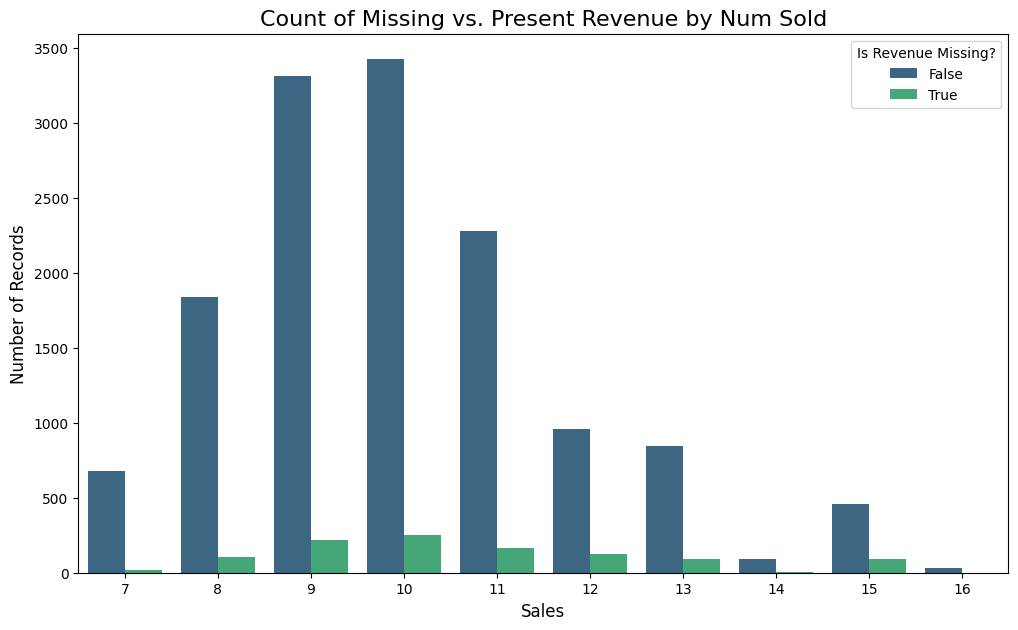

In [82]:
# --- Step 2: Create a helper column to flag missing revenue ---
clean_df['revenue_is_missing'] = clean_df['revenue'].isnull()

# --- Step 3: Visualize the count of missing vs. non-missing by region ---
plt.figure(figsize=(12, 7))

# Use countplot with 'region' on the x-axis and the new boolean column as the hue
sns.countplot(data=clean_df, x='nb_sold', hue='revenue_is_missing', palette='viridis')

plt.title('Count of Missing vs. Present Revenue by Num Sold', fontsize=16)
plt.xlabel('Sales', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.legend(title='Is Revenue Missing?')
plt.show()

In [83]:
# Cleaning revenue column
# Missing value precentage ~ 7% (dropped)
clean_df = clean_df.dropna(subset=['revenue'])
clean_df['revenue'] = round(clean_df['revenue'], 2)

In [84]:
# The values in the years_as_customer cannot be more than 41 as company was founded in 1984 and present year is 2025
# Use clip() to cap the values at an upper bound of 41.
# This operation returns a new Series, so we must assign it back.
clean_df['years_as_customer'] = clean_df['years_as_customer'].clip(upper=41)

In [85]:
# droping uneccesary columns
clean_df.drop('revenue_is_missing', axis=1, inplace=True)

In [86]:
clean_df.dtypes

week                   int64
sales_method          object
customer_id           object
nb_sold                int64
revenue              float64
years_as_customer      int64
nb_site_visits         int64
state                 object
dtype: object

In [87]:
clean_df['week'].value_counts(dropna=False)

week
1    3497
4    2387
5    2366
2    2323
3    2257
6    1096
Name: count, dtype: int64

In [88]:
# making sure there are 50 unique values in state column
clean_df['state'].value_counts(dropna=False).count()

50

In [89]:
clean_df

,week,sales_method,customer_id,nb_sold,revenue,years_as_customer,nb_site_visits,state
1,6,Email + Call,3998a98d-70f5-44f7-942e-789bb8ad2fe7,15,225.47,1,28,Kansas
2,5,Call,d1de9884-8059-4065-b10f-86eef57e4a44,11,52.55,6,26,Wisconsin
4,3,Email,10e6d446-10a5-42e5-8210-1b5438f70922,9,90.49,0,28,Illinois
5,6,Call,6489e678-40f2-4fed-a48e-d0dff9c09205,13,65.01,10,24,Mississippi
6,4,Email,eb6bd5f1-f115-4e4b-80a6-5e67fcfbfb94,11,113.38,9,28,Georgia
...,...,...,...,...,...,...,...,...
14994,4,Email,56f02e26-3633-427d-8c4e-f45f00afa787,11,109.36,3,25,Ohio
14995,4,Call,17267b41-d048-4346-8b90-7f787690a836,10,50.82,0,22,Pennsylvania
14996,5,Call,09e10d6f-4508-4b27-895e-4db11ce8302b,10,52.33,1,27,Kansas
14997,1,Call,839653cb-68c9-48cb-a097-0a5a3b2b298b,7,34.87,4,22,West Virginia


##  Data Validation

The dataset contains **15000 rows × 8 columns** before cleaning and validataion. I have validated all the columns against the criteria in the dataset table:

- week: 6 weeks, 1 to 6 without missing values, same as the description. No cleaning is needed.
- sales_method: *3 unique values of 3 categories, some data cleaning required like replacing "em + call" with "Email + Call" and "email" with "Email".
- customer_id: alpha-numeric unique values without missing values, same as the description. No cleaning is needed.
- nb_sold: numeric values without missing values, same as the description. No cleaning is needed.
- revenue: missing values accounted for just about 7% of the total hence dropped rows with missing values.
- years_as_customer: numeric values that cannot be more than 41 (2025-1984). Values greater than 41 (2 values) replaced by 41.
- nb_site_visits: numeric values without missing values, same as the description. No cleaning is needed.
- state: 50 possible values without missing values, same as the description. No cleaning is needed.

After the data validation, the dataset contains **13926 rows × 8 columns** without missing values.


# Exploratory Data Analysis

In [90]:
clean_df.head(9)

,week,sales_method,customer_id,nb_sold,revenue,years_as_customer,nb_site_visits,state
1,6,Email + Call,3998a98d-70f5-44f7-942e-789bb8ad2fe7,15,225.47,1,28,Kansas
2,5,Call,d1de9884-8059-4065-b10f-86eef57e4a44,11,52.55,6,26,Wisconsin
4,3,Email,10e6d446-10a5-42e5-8210-1b5438f70922,9,90.49,0,28,Illinois
5,6,Call,6489e678-40f2-4fed-a48e-d0dff9c09205,13,65.01,10,24,Mississippi
6,4,Email,eb6bd5f1-f115-4e4b-80a6-5e67fcfbfb94,11,113.38,9,28,Georgia
7,1,Email,047df079-071b-4380-9012-2bfe9bce45d5,10,99.94,1,22,Oklahoma
8,5,Email,771586bd-7b64-40be-87df-afe884d2af9e,11,108.34,10,31,Massachusetts
9,5,Call,56491dae-bbe7-49f0-a651-b823a01103d8,11,53.82,7,23,Missouri
10,3,Email,c40f2602-8a7c-429e-bf13-cb1ec9e5f92f,9,89.49,4,28,Texas


In [91]:
clean_df['customer_id'].is_unique
# this means all customers listed in the table ordered just once in the last 6 weeks

True

## Why Emailing is a No Brainer?
As we can see for from the Revenue distribution, the Email method of sales clearly owns a major chunk of the revenue. It also has the highest total revenue, highest total sales and the highest total no of customers. The call method might seem to rival it but it brings in a lot less revenue on average. Additionally in 98% of the states, Email is the sales method that drove most of the revenue as shown in the pie chart. This tells us that email as a sales method is highly effective and is a no brainer for the business. We need to now see what are the strengths of Email + Call over just email.

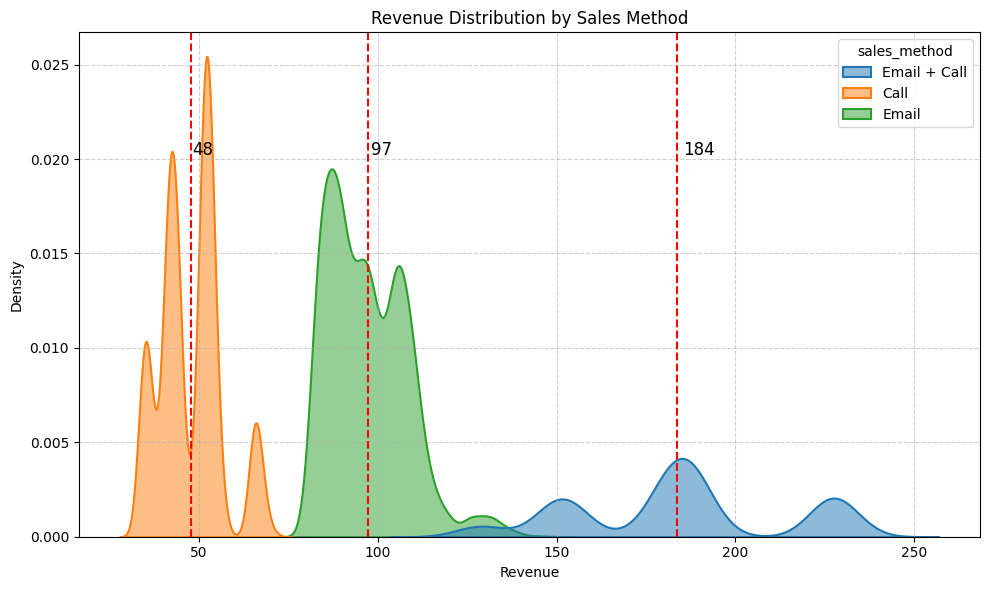

In [92]:
# Distriution of Revenue per Sales Method
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=clean_df[['revenue', 'sales_method']], 
    x='revenue', 
    hue='sales_method', 
    fill=True, 
    common_norm=True,
    alpha=0.5,
    linewidth=1.5
)

# Add red dotted mean lines and annotate exact values
mean_revenues = clean_df.groupby('sales_method')['revenue'].mean()
for mean_value in mean_revenues:
    plt.axvline(mean_value, color='red', linestyle='--', linewidth=1.5)
    plt.text(mean_value + 0.01*mean_value, 0.02, f'{mean_value:.0f}', 
             color='black', va='bottom', ha='left', fontsize=12)

plt.title('Revenue Distribution by Sales Method') 
plt.xlabel('Revenue') 
plt.ylabel('Density') 
plt.tight_layout() 
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('/Volumes/Storage Extra/Data Science/Projects/datasciencenotebooks/product_sales_method/images/revdist_per_method.png', dpi=300, bbox_inches='tight')
plt.show()

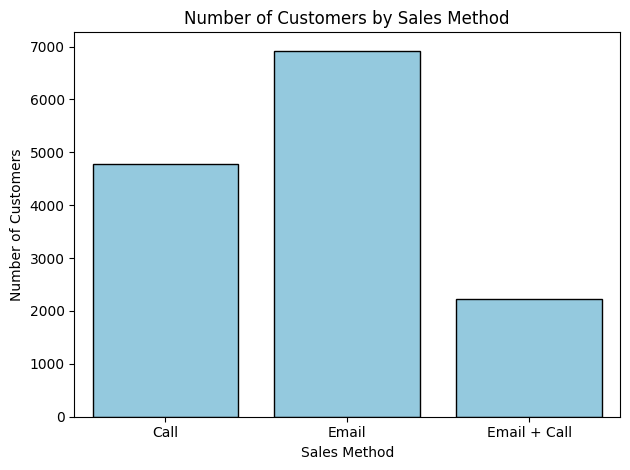

In [93]:
# No of customers per each sales method
customers_by_method = clean_df.groupby('sales_method', as_index=False)['customer_id'].count()

# Barplot of number of customers per sales method
sns.barplot(
    data=customers_by_method,
    x='sales_method',
    y='customer_id',
    color='skyblue',
    legend=False,
    edgecolor='black'
)

plt.title('Number of Customers by Sales Method')
plt.xlabel('Sales Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/Volumes/Storage Extra/Data Science/Projects/datasciencenotebooks/product_sales_method/images/customers_per_method.png', dpi=300, bbox_inches='tight')
plt.show()

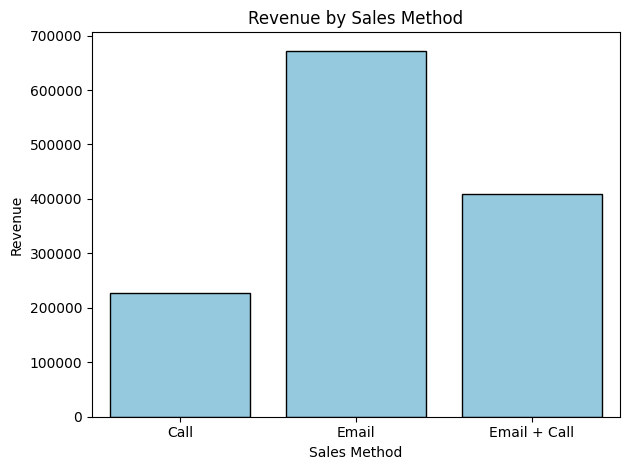

In [94]:
# Aggregate total revenue per sales method
revenue_by_method = clean_df.groupby('sales_method', as_index=False)['revenue'].sum()

# Barplot of revenue per sales method
sns.barplot(
    data=revenue_by_method,
    x='sales_method',
    y='revenue',
    color='skyblue',
    legend=False,
    edgecolor='black'
)

plt.title('Revenue by Sales Method')
plt.xlabel('Sales Method')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/Volumes/Storage Extra/Data Science/Projects/datasciencenotebooks/product_sales_method/images/revenue_per_method.png', dpi=300, bbox_inches='tight')
plt.show()

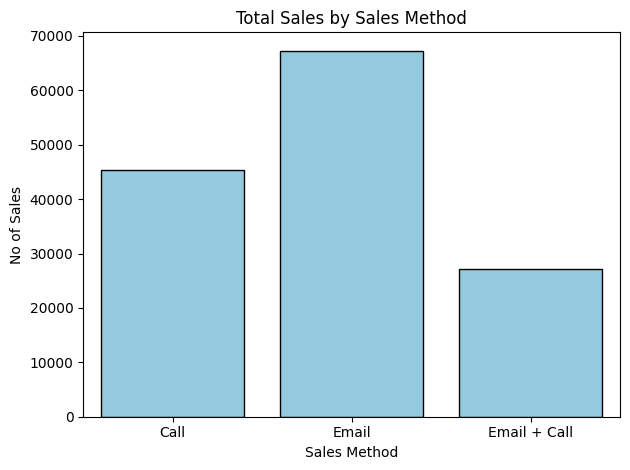

In [95]:
# Sales method by nb_sold
sales_by_method = clean_df.groupby('sales_method')['nb_sold'].agg('sum')

sns.barplot(
    x=sales_by_method.index,
    y=sales_by_method.values,
    color='skyblue',
    legend=False,
    edgecolor='black'
)

plt.title('Total Sales by Sales Method')
plt.xlabel('Sales Method')
plt.ylabel('No of Sales')
plt.tight_layout()
plt.savefig('/Volumes/Storage Extra/Data Science/Projects/datasciencenotebooks/product_sales_method/images/sales_per_method.png', dpi=300, bbox_inches='tight')
plt.show()

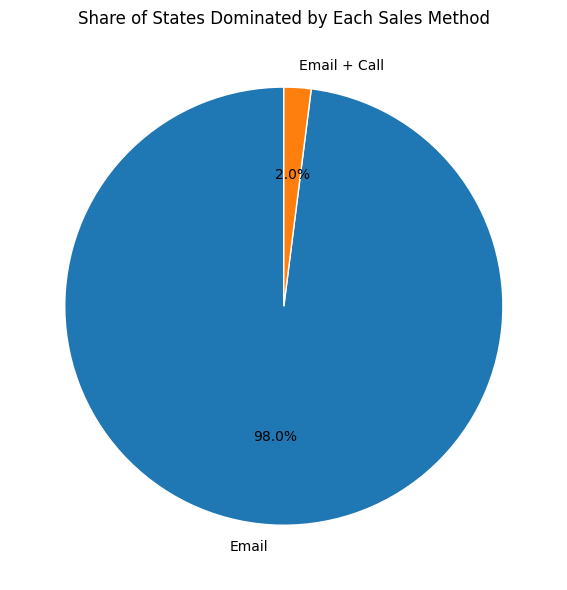

In [96]:
# Step 1: Aggregate total sales per (state, sales_method)
state_sales = clean_df.groupby(['state', 'sales_method'])['revenue'].sum().reset_index()

# Step 2: For each state, find which sales method had the max sales
top_method_by_state = state_sales.loc[state_sales.groupby('state')['revenue'].idxmax()]

# Step 3: Count how many states were dominated by each method
method_counts = top_method_by_state['sales_method'].value_counts()

# Step 4: Pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    method_counts,
    labels=method_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)

plt.title('Share of States Dominated by Each Sales Method')
plt.tight_layout()
plt.savefig('/Volumes/Storage Extra/Data Science/Projects/datasciencenotebooks/product_sales_method/images/state_dominated_method.png', dpi=300, bbox_inches='tight')
plt.show()


## Why Email + Call is a Fantastic Idea?
We see that Email + Call method is on the higher end of the sales distribution. It also has the highest average selling price out of the three. We can say that Email + Call is selling more to a premium customer segment. Email is good in general but for the premium customers segment, Email + Call can be said to be more apt as they would appreciate the personalised touch of the call. We can also see that Email + Call had the highest median number of website visits by the boxplot diagram and higher website visits equals higher revenue as seen in the scatter diagrams.

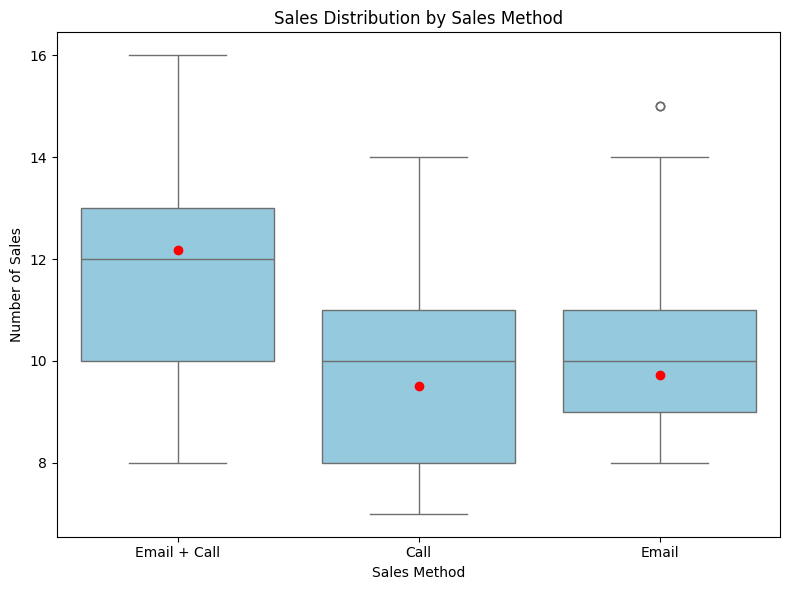

In [97]:
# Boxplot of Sales per Sales Method
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=clean_df,
    x='sales_method',
    y='nb_sold',
    color='skyblue',
    legend=False,
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "red"}
)

plt.title('Sales Distribution by Sales Method')
plt.xlabel('Sales Method')
plt.ylabel('Number of Sales')
plt.tight_layout()
plt.savefig('/Volumes/Storage Extra/Data Science/Projects/datasciencenotebooks/product_sales_method/images/salesdist_per_method.png', dpi=300, bbox_inches='tight')
plt.show()

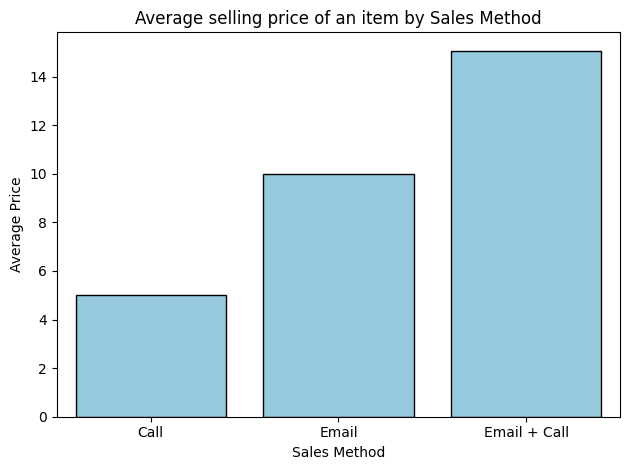

In [98]:
# Sales_method vs total Revenue/total nb_sold
average_price = clean_df.groupby('sales_method').agg(
    revenue=('revenue', 'sum'),
    items=('nb_sold', 'sum')
)

average_price['avg_price'] = average_price['revenue'] / average_price['items']

# Average selling price of an item
sns.barplot(
    data=average_price,
    x='sales_method',
    y='avg_price',
    color='skyblue',
    legend=False,
    edgecolor='black'
)

plt.title('Average selling price of an item by Sales Method')
plt.xlabel('Sales Method')
plt.ylabel('Average Price')
plt.tight_layout()
plt.savefig('/Volumes/Storage Extra/Data Science/Projects/datasciencenotebooks/product_sales_method/images/avgsp_per_method.png', dpi=300, bbox_inches='tight')
plt.show()

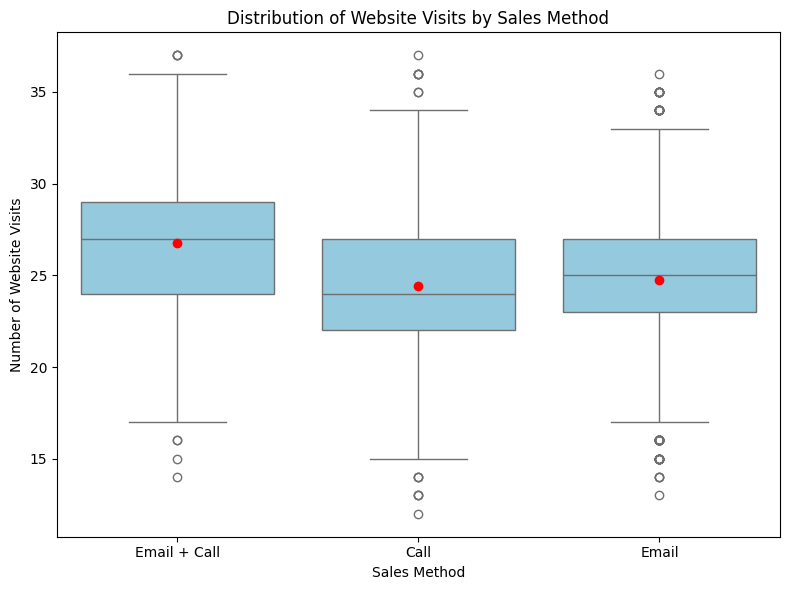

In [99]:
# Boxplot of Website Visits per Sales Method
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=clean_df,
    x='sales_method',
    y='nb_site_visits',
    color='skyblue',
    legend=False,
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "red"}
)

plt.title('Distribution of Website Visits by Sales Method')
plt.xlabel('Sales Method')
plt.ylabel('Number of Website Visits')
plt.tight_layout()
plt.savefig('/Volumes/Storage Extra/Data Science/Projects/datasciencenotebooks/product_sales_method/images/webvisit_per_method.png', dpi=300, bbox_inches='tight')
plt.show()

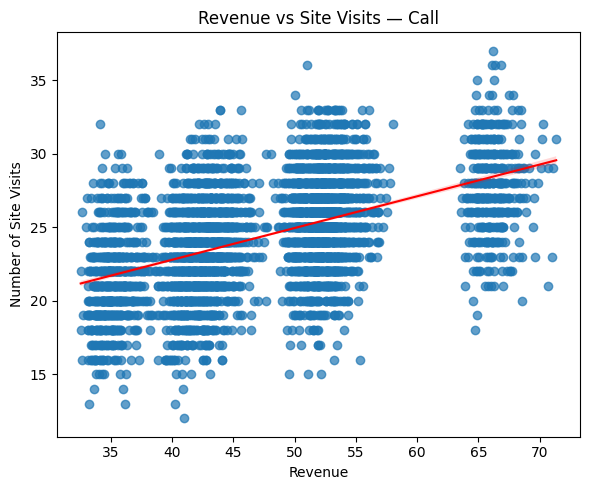

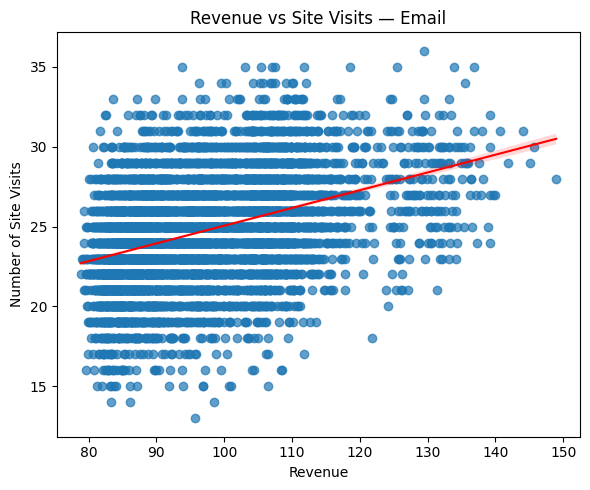

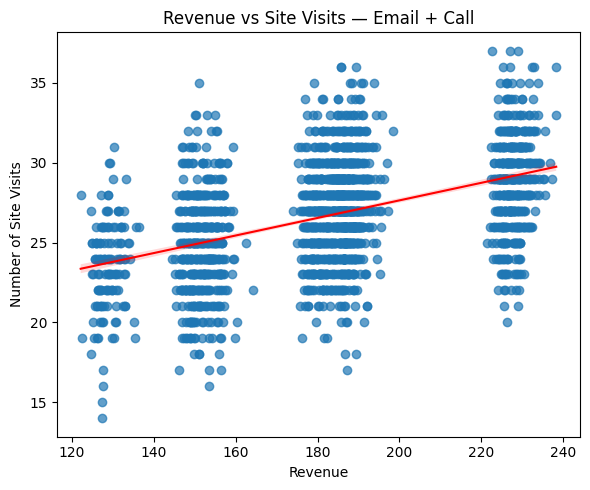

In [100]:
# Loop through each sales method group
for method, group in clean_df.groupby('sales_method'):
    plt.figure(figsize=(6, 5))
    
    # Scatter plot with regression line
    sns.regplot(
        data=group,
        x='revenue',
        y='nb_site_visits',
        scatter_kws={'alpha': 0.7},
        line_kws={'color': 'red', 'linewidth': 1.5}
    )
    
    plt.title(f'Revenue vs Site Visits — {method}')
    plt.xlabel('Revenue')
    plt.ylabel('Number of Site Visits')
    
    plt.tight_layout()
    plt.savefig(f'/Volumes/Storage Extra/Data Science/Projects/datasciencenotebooks/product_sales_method/images/{method}_revenue_by_webvisit.png', dpi=300, bbox_inches='tight')
    plt.show()

## Few More Perks of the Follow Up Call

Email is a must but the follow up call works is in our favor. We can see that over time more the revenue and the sales associated with Email + Call have risen unlike the others. This is could be due to the follow up call. Additionally Email + Call as method has converted slightly more of the newer customers. That is the follow up call is a good sales method for new customers. The follow up call would also provide for a good customer relation. Additionally, customers will not forget about Pens and Printers once the sale is over.

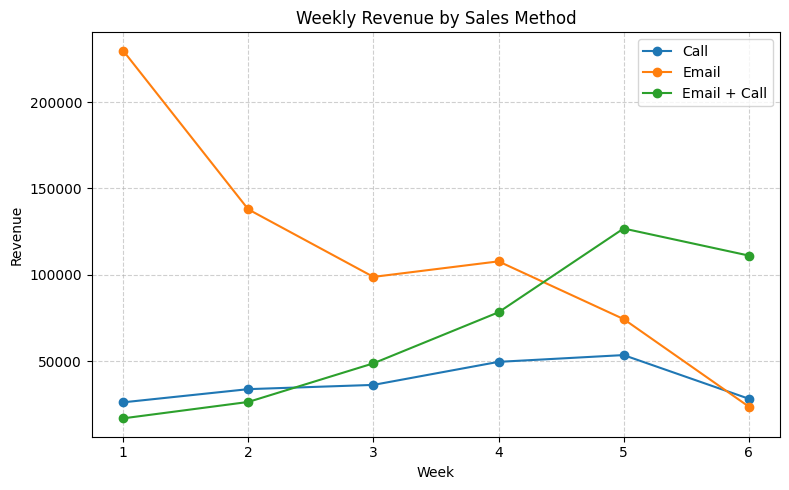

In [101]:
# Revenue per sales method over time
call_method_revenue = clean_df[clean_df['sales_method']=='Call'].groupby('week')['revenue'].agg('sum')
email_method_revenue = clean_df[clean_df['sales_method']=='Email'].groupby('week')['revenue'].agg('sum')
both_method_revenue = clean_df[clean_df['sales_method']=='Email + Call'].groupby('week')['revenue'].agg('sum')

df = pd.concat([call_method_revenue, email_method_revenue, both_method_revenue], axis=1)
df.columns = ['Call', 'Email', 'Email + Call']  # rename columns

df.plot(kind='line', marker='o', figsize=(8,5), title='Weekly Revenue by Sales Method')
plt.xlabel('Week')
plt.ylabel('Revenue')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/Volumes/Storage Extra/Data Science/Projects/datasciencenotebooks/product_sales_method/images/weeklyrev_per_method.png', dpi=300, bbox_inches='tight')
plt.show()

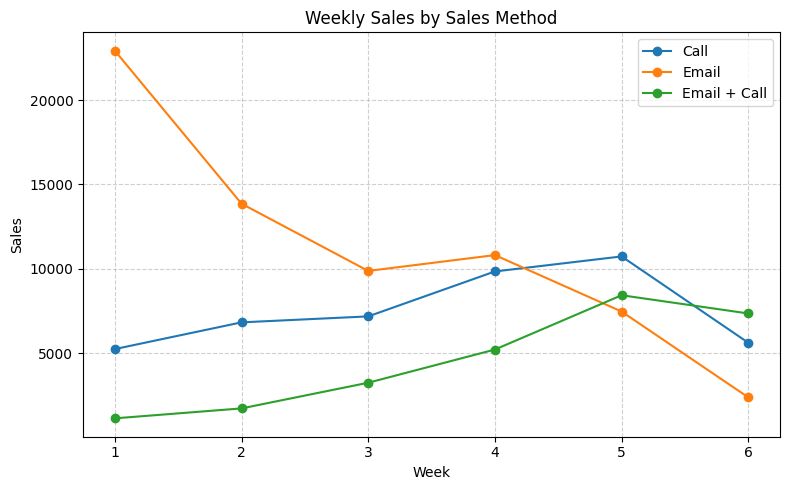

In [102]:
# Revenue per sales method over time
call_method_sales = clean_df[clean_df['sales_method']=='Call'].groupby('week')['nb_sold'].agg('sum')
email_method_sales = clean_df[clean_df['sales_method']=='Email'].groupby('week')['nb_sold'].agg('sum')
both_method_sales = clean_df[clean_df['sales_method']=='Email + Call'].groupby('week')['nb_sold'].agg('sum')

df = pd.concat([call_method_sales, email_method_sales, both_method_sales], axis=1)
df.columns = ['Call', 'Email', 'Email + Call']  # rename columns

df.plot(kind='line', marker='o', figsize=(8,5), title='Weekly Sales by Sales Method')
plt.xlabel('Week')
plt.ylabel('Sales')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/Volumes/Storage Extra/Data Science/Projects/datasciencenotebooks/product_sales_method/images/weeklysales_per_method.png', dpi=300, bbox_inches='tight')
plt.show()

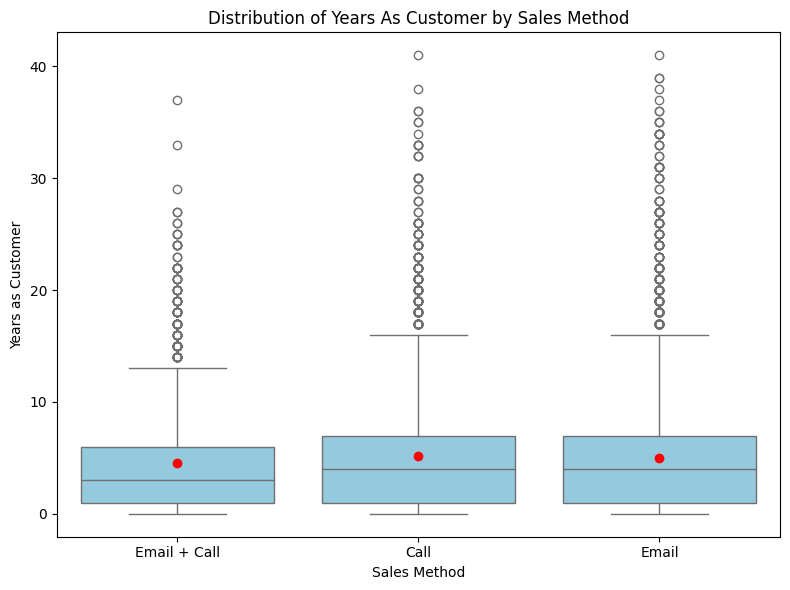

In [103]:
# Boxplot of Years as Customer per Sales Method
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=clean_df,
    x='sales_method',
    y='years_as_customer',
    color='skyblue',
    legend=False,               # Hide duplicate legend
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "red"}
)

plt.title('Distribution of Years As Customer by Sales Method')
plt.xlabel('Sales Method')
plt.ylabel('Years as Customer')
plt.tight_layout()
plt.savefig('/Volumes/Storage Extra/Data Science/Projects/datasciencenotebooks/product_sales_method/images/custyearsdist_per_method.png', dpi=300, bbox_inches='tight')
plt.show()

## Business Metrics
The objective isn’t just to sell, but to sell effectively — which implies efficiency and impact, not just activity. Since we are launching a new product, effectiveness means:

- The sales method is converting customers well. 

- It’s profitable (brings good revenue per effort).

- It’s scalable and sustainable (can be repeated without excessive cost).

As data is limited, I would recommend we use **Average Revenue per Customer per Sales Method in the last 6 weeks** as our main metric for now.

Based on our last 6 week data, 184 dollars was Average Revenue per Customer per Email + Call, followed by Email at 97 dollars and finally Call had an average revenue per customer of 48 dollars. According to the metric, Email + Call is preferred. Therefore, if this number for a particular sales method is increasing in next 6 week, it indicates a good sales method to achieve our goal.

## Recommendations
For the following weeks, I would recommend we can focus on the following steps:
- Using key metrics to monitor which sales method is the most effective for the new product line.
- To not just sell, but to sell effectively, we should smartly smartly choose our sales method:
  - Treat email as the primary and mandatory sales method.
  - Send follow up calls to selective customer segments like premium customers and newer customers.
- Stay on top of the current demand for office stationery market and consumers' buying patterns so that the newest information can be integrated in sales.
- Data Collection for in-depth analysis
  - New relevant data to be included - Track customer exposure or cost per sale as that would give as a better metric for assessment: “Conversion Rate” or “Revenue per Contact”.
  - These tell you which channel is truly effective at driving valuable behavior, not just volume.